# Correlation structure of differential aerosol size bins (NorESM & EC-Earth)

**Scientific question.** When CCN number is integrated up to a series of cutoff
diameters and then *differenced* between adjacent cutoffs, each difference is the
particle count in a narrow diameter band. How correlated are these size bands
with one another, within each model (NorESM/OsloAero and EC-Earth), both pooled
across all samples and station by station?

Strong off-diagonal correlation means neighbouring size bands carry redundant
information (the size distribution varies coherently); block structure in the
heatmap separates size ranges that vary independently — e.g. Aitken vs
accumulation populations.

**Method.** For each model, the ERF integration gives cumulative CCN up to each
radius. Differencing adjacent radii yields per-band counts; flattening over the
sampling dimensions and taking `np.corrcoef` across bands gives the band-to-band
Pearson correlation matrix.

## 1 · Setup and configuration

A single canonical radius grid is used everywhere (`RADIUS_GRID`,
`np.linspace(0, 200, 41)` — radius in nm, so bands span diameters up to 400 nm).

**Performance note.** The ERF integration is the expensive step, so it is run
**once per model** and immediately materialised into an in-memory band tensor
with `build_band_tensor`. Both the pooled and per-station correlation matrices
are then sliced from that NumPy array — nothing re-triggers the lazy ERF graph.
The earlier version recomputed the ERF for every station panel (≈16× per model),
which was the main cost.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

import PeterChurchillFunctions as Function

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
NOR_PATH = (
    "/share/sabl0586/all_stations_NorESM_OsloAero_"
    "prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
)
EC_PATH  = "/share/pech2273/EC_Earth_Data.nc"

RADIUS_GRID = np.linspace(0, 200, 41)   # canonical radius grid [nm]
TICK_EVERY  = 5                          # show every Nth band label on heatmaps


def build_band_tensor(corr_ds):
    """Materialise the differential size-band tensor from an ERF dataset, once.

    Differences adjacent radii in a single vectorised ``.diff('radius')`` (no
    Python loop), keeps the ``station`` dimension, and triggers exactly one
    ``.compute()`` so the lazy ERF graph runs a single time.

    Parameters
    ----------
    corr_ds : xarray.DataArray
        ERF output (cumulative CCN) with dims including ``radius`` and
        ``station`` plus sampling dims (time, lev, ...).

    Returns
    -------
    bands : numpy.ndarray
        Shape ``(n_bands, n_station, *sample_shape)`` — per-band counts.
        Band b = CCN(radius_b) - CCN(radius_{b+1}).
    stations : numpy.ndarray
        Station coordinate values, aligned with ``bands`` axis 1.
    labels : list of str
        Diameter-band labels 'D0-D1' (nm).
    """
    rv = corr_ds.radius.values
    labels = [f"{rv[r] * 2:.0f}-{rv[r + 1] * 2:.0f}" for r in range(len(rv) - 1)]

    # Adjacent-radius difference: CCN(r) - CCN(r+1). .diff gives CCN(r+1)-CCN(r),
    # so negate. One vectorised op over the whole array, then one compute().
    band_da = (-corr_ds.diff("radius")).compute()

    # Move 'radius' (now the band axis) and 'station' to the front
    other = [d for d in band_da.dims if d not in ("radius", "station")]
    band_da = band_da.transpose("radius", "station", *other)
    return band_da.values, corr_ds.station.values, labels


def correlation_matrix(bands, station_idx=None):
    """Band-to-band Pearson correlation from a precomputed band tensor.

    Parameters
    ----------
    bands : numpy.ndarray
        ``(n_bands, n_station, *sample)`` tensor from ``build_band_tensor``.
    station_idx : int, optional
        If given, restrict to that station (axis 1); else pool all stations.

    Returns
    -------
    numpy.ndarray
        ``(n_bands, n_bands)`` correlation matrix.
    """
    sub = bands if station_idx is None else bands[:, station_idx]
    flat = sub.reshape(sub.shape[0], -1)           # (n_bands, n_samples)
    finite = np.isfinite(flat).all(axis=0)         # drop non-finite samples
    return np.corrcoef(flat[:, finite])


def plot_corr_heatmap(corr_matrix, labels, ax=None, title="", show_cbar=True,
                      tick_every=TICK_EVERY):
    """Draw one band-correlation heatmap with thinned tick labels."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, ax=ax, xticklabels=labels, yticklabels=labels,
                cmap="RdYlBu_r", vmin=-1, vmax=1, square=True,
                cbar=show_cbar, cbar_kws={"label": "Pearson r"})
    ax.set_title(title)
    ax.set_xlabel("Diameter (nm)")
    ax.set_ylabel("Diameter (nm)")
    for k, lab in enumerate(ax.get_xticklabels()):
        if k % tick_every != 0:
            lab.set_visible(False)
    for k, lab in enumerate(ax.get_yticklabels()):
        if k % tick_every != 0:
            lab.set_visible(False)
    return ax


def all_station_matrices(bands):
    """Stack of per-station correlation matrices: (n_station, n_bands, n_bands)."""
    return np.stack([correlation_matrix(bands, station_idx=s)
                     for s in range(bands.shape[1])])

## 2 · NorESM size-band correlations

Run the ERF once, materialise the band tensor, then derive the pooled matrix
(and, later, the per-station matrices) by slicing that array.

In [ ]:
ds_nor = xr.open_dataset(NOR_PATH, chunks={})

nor_corr_ds = Function.NorERF(ds_nor, RADIUS_GRID)
nor_bands, nor_stations, nor_labels = build_band_tensor(nor_corr_ds)
nor_corr = correlation_matrix(nor_bands)          # pooled
print(f"NorESM band tensor: {nor_bands.shape}  (n_bands, n_station, *sample)")

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in log
  return func(*(_execute_task(a, cache) for a in args))


NorESM band tensor: (40, 15, 8761, 32)  (n_bands, n_station, *sample)


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in log
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


### Figure 1 — NorESM pooled band correlation

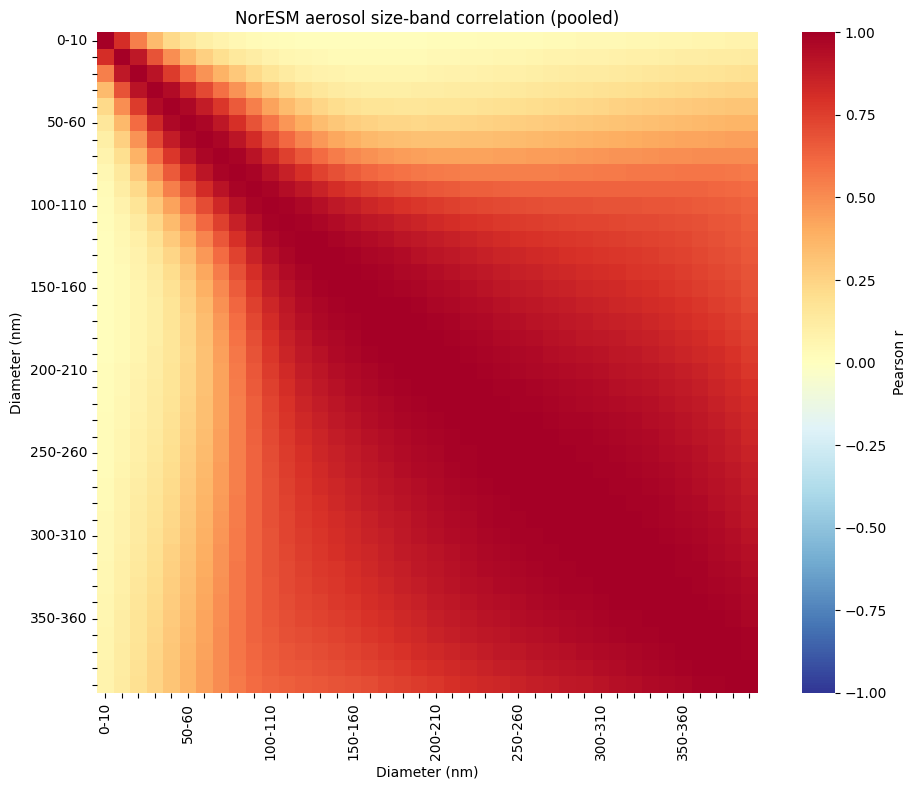

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_corr_heatmap(nor_corr, nor_labels, ax=ax,
                  title="NorESM aerosol size-band correlation (pooled)")
fig.tight_layout()
plt.show()

### Figure 2 — NorESM per-station band correlation

One heatmap per station (3×5 grid), each sliced from the in-memory band tensor;
the colorbar is shown once on the last panel.

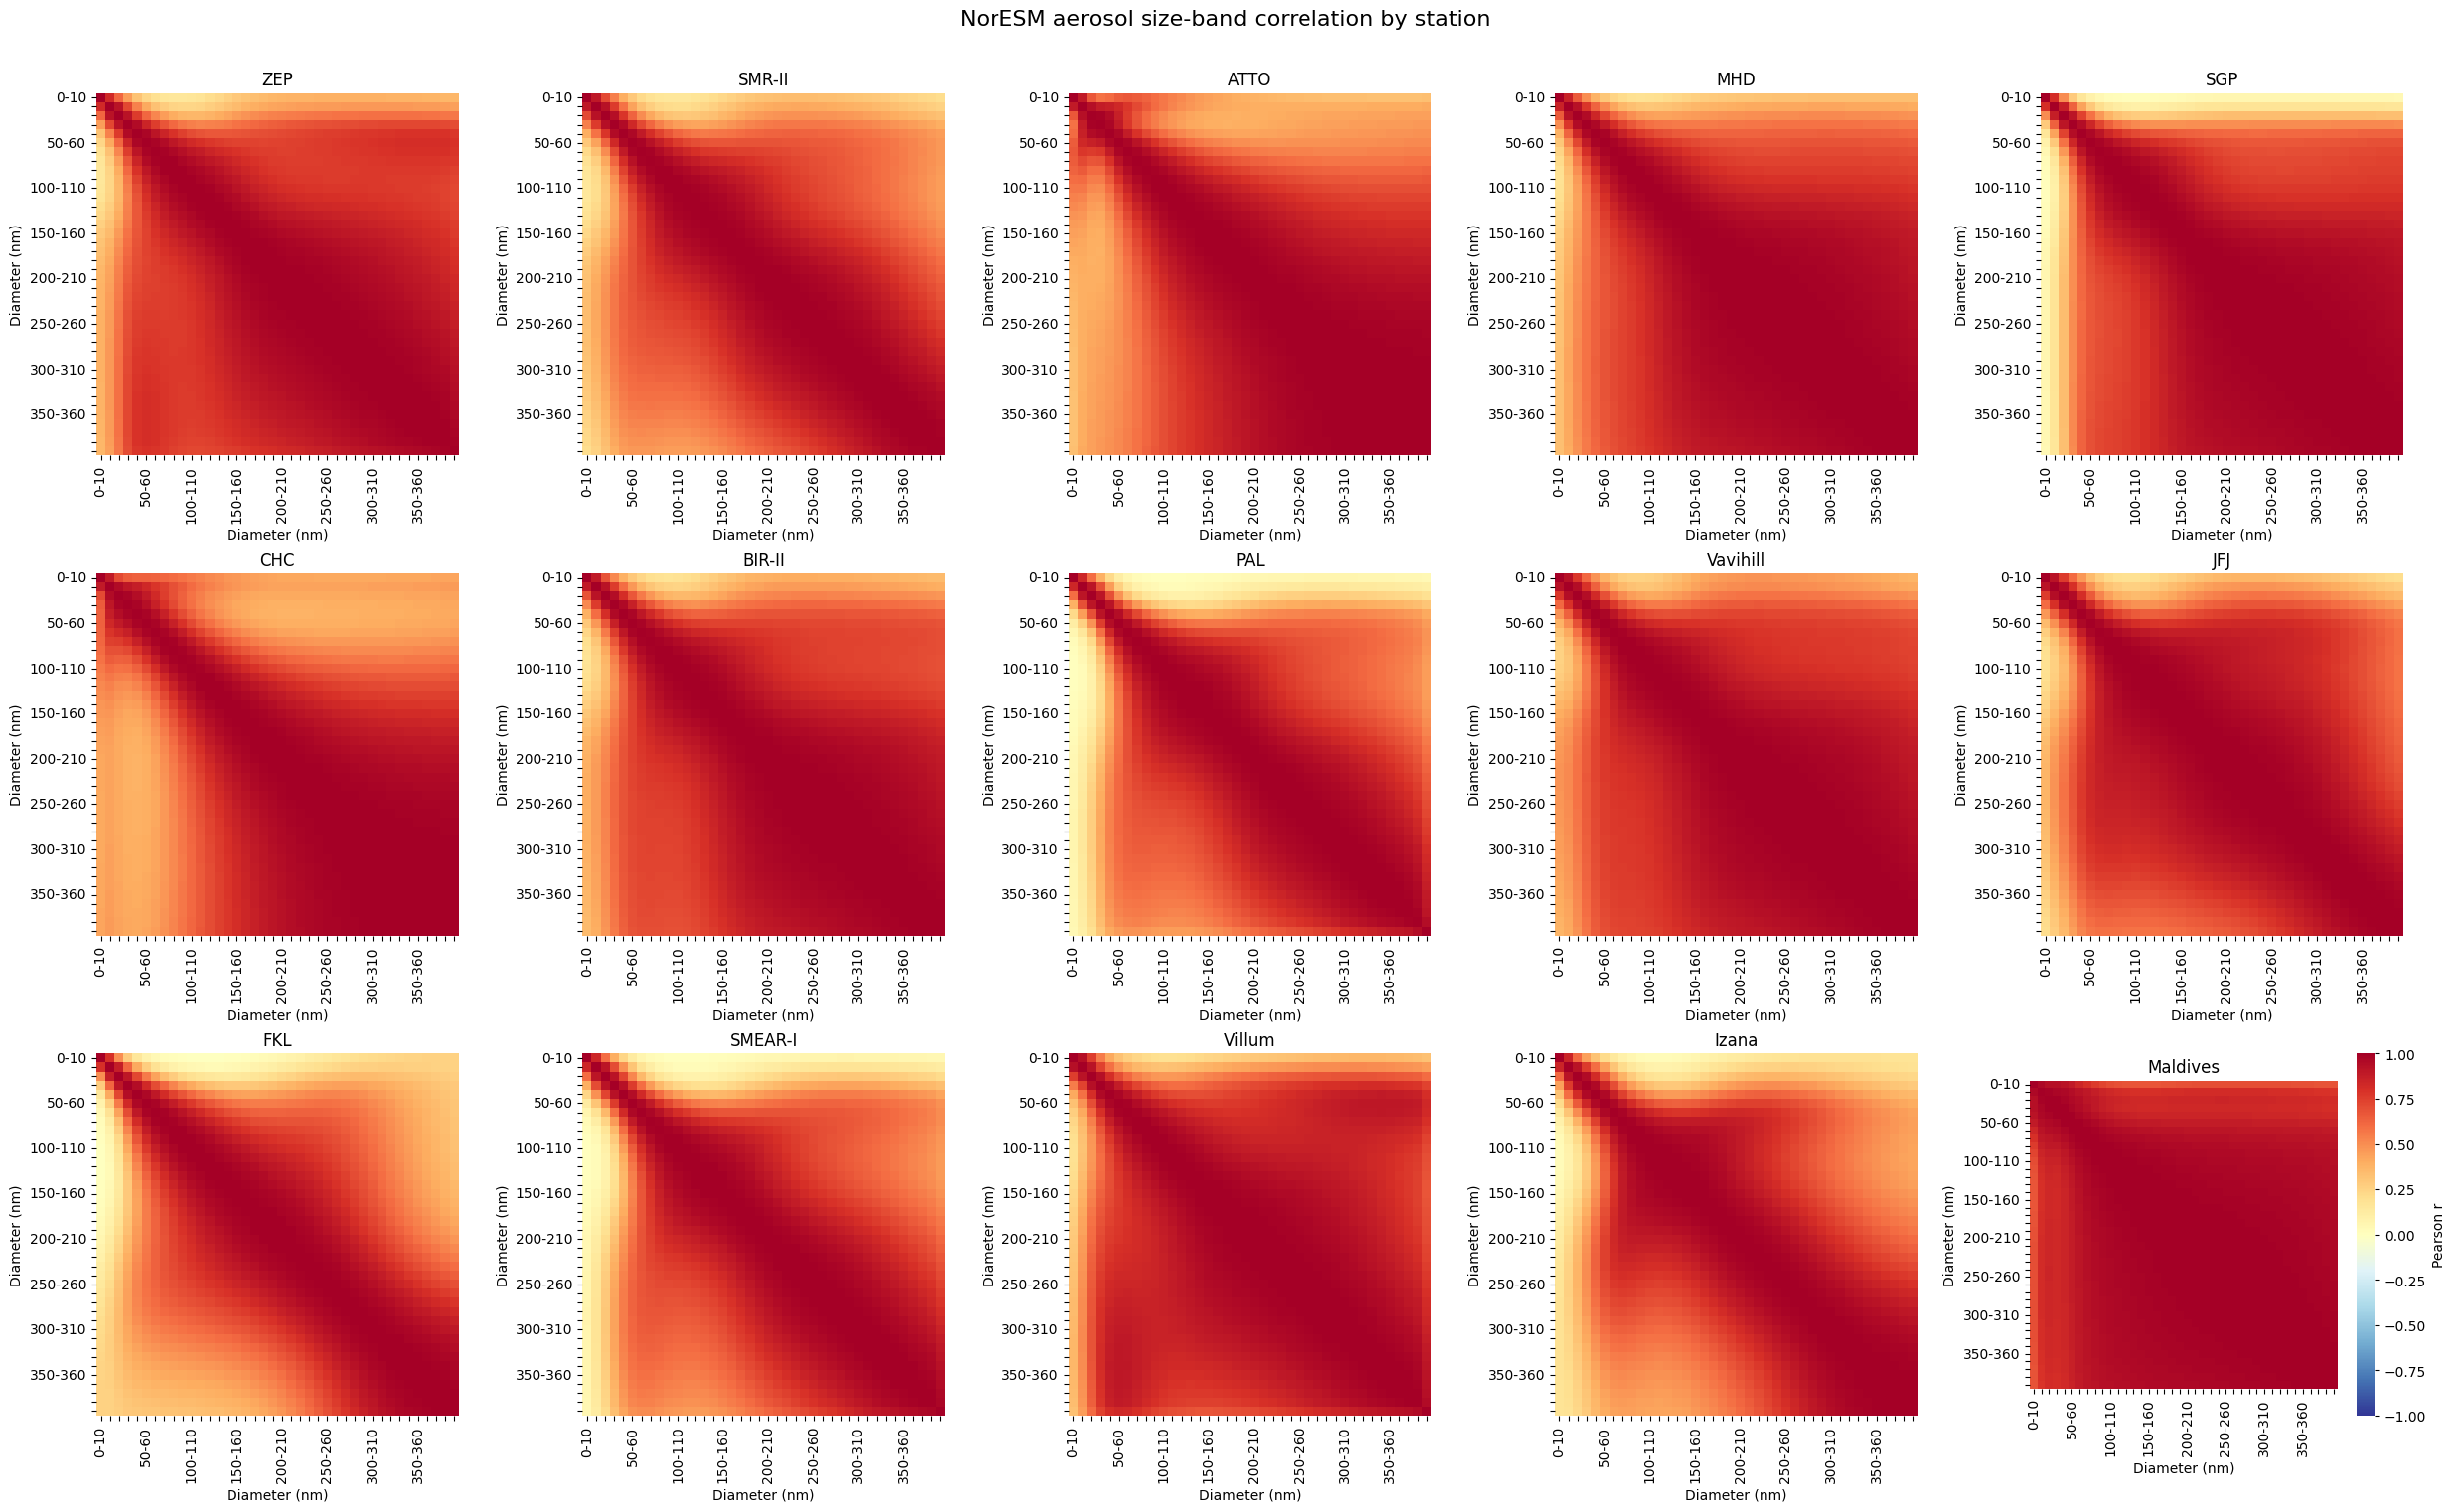

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(25, 15))
for idx, station in enumerate(nor_stations):
    ax = axes[idx // 5, idx % 5]
    cm = correlation_matrix(nor_bands, station_idx=idx)
    plot_corr_heatmap(cm, nor_labels, ax=ax, title=str(station),
                      show_cbar=(idx == len(nor_stations) - 1))
for j in range(len(nor_stations), axes.size):
    axes.flat[j].axis("off")
fig.suptitle("NorESM aerosol size-band correlation by station", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

### Optional — persist NorESM per-station matrices

Reuses the already-computed band tensor, so the stack is essentially free.

In [5]:
# nor_corr_matrices = all_station_matrices(nor_bands)
# NorCorrMat_ds = xr.Dataset(
#     {"corr": (["station", "bin_x", "bin_y"], nor_corr_matrices)},
#     coords={"station": nor_stations, "bin_x": nor_labels, "bin_y": nor_labels},
# )
# NorCorrMat_ds.to_netcdf("/share/pech2273/NorESMcorr_matrices.nc")

## 3 · EC-Earth size-band correlations

EC-Earth stores per-mode dry/wet radii and number concentrations under IFS
variable names. Before the ERF integration we normalise units: radii from m to
nm (×1e9) and number from m⁻³ to cm⁻³ (÷1e6).

In [6]:
ds_ec = xr.open_dataset(EC_PATH).chunk(time=1000)
ds_ec = ds_ec.sel(time=slice("2012-01-01T03:00:00", "2015-01-01T03:00:00"))

# Mode radius / number variables
radius_variables = ["RDRY_NUS", "RDRY_AIS", "RDRY_ACS", "RWET_AII",
                    "RDRY_COS", "RWET_ACI", "RWET_COI"]
numb_variables   = ["N_NUS", "N_AIS", "N_ACS", "N_AII",
                    "N_COS", "N_ACI", "N_COI"]

for rvar, nvar in zip(radius_variables, numb_variables):
    if rvar not in ds_ec or nvar not in ds_ec:
        print(f"{(rvar, nvar)} not found in EC-Earth data")
        continue
    if ds_ec[rvar].attrs.get("units") == "m":
        ds_ec[rvar] = ds_ec[rvar] * 1e9              # m -> nm
        ds_ec[rvar].attrs["units"] = "nm"
        print(f"{rvar} converted to nm")
    if ds_ec[nvar].attrs.get("units") == "1 m-3":
        ds_ec[nvar] = ds_ec[nvar] / 1e6              # m^-3 -> cm^-3
        ds_ec[nvar].attrs["units"] = "#cm-3"
        print(f"{nvar} converted to cm^-3")

RDRY_NUS converted to nm
N_NUS converted to cm^-3
RDRY_AIS converted to nm
N_AIS converted to cm^-3
RDRY_ACS converted to nm
N_ACS converted to cm^-3
RWET_AII converted to nm
N_AII converted to cm^-3
RDRY_COS converted to nm
N_COS converted to cm^-3
RWET_ACI converted to nm
N_ACI converted to cm^-3
RWET_COI converted to nm
N_COI converted to cm^-3


In [7]:
ec_corr_ds = Function.ECEarthERF(ds_ec, RADIUS_GRID)
ec_bands, ec_stations, ec_labels = build_band_tensor(ec_corr_ds)
ec_corr = correlation_matrix(ec_bands)            # pooled
print(f"EC-Earth band tensor: {ec_bands.shape}  (n_bands, n_station, *sample)")

EC-Earth band tensor: (40, 15, 8766, 34)  (n_bands, n_station, *sample)


### Figure 3 — EC-Earth pooled band correlation

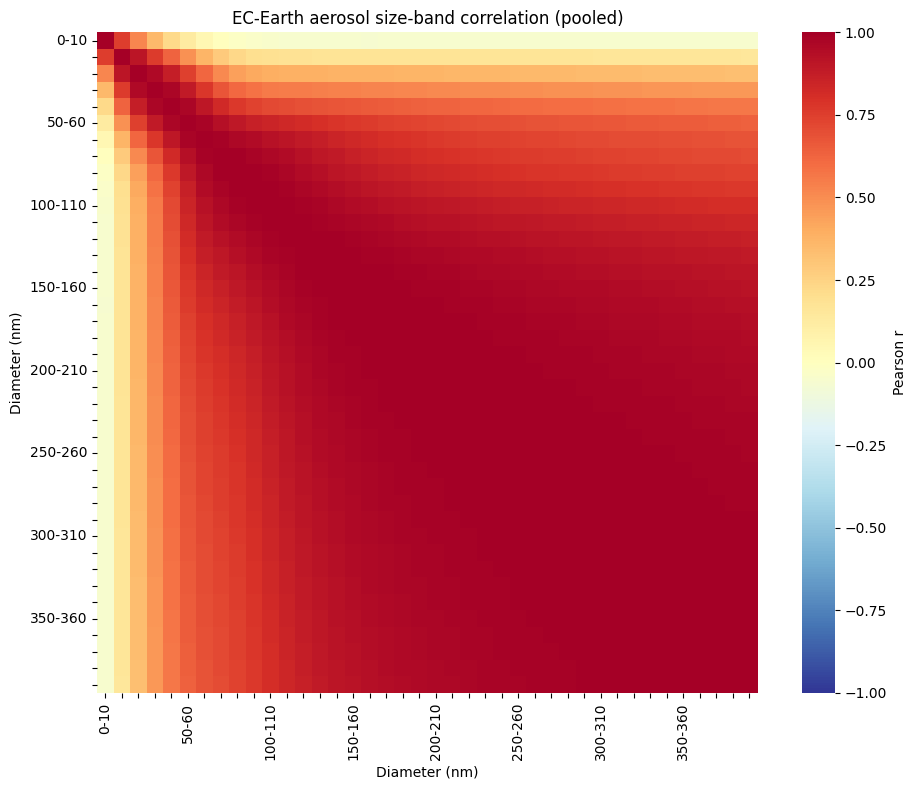

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_corr_heatmap(ec_corr, ec_labels, ax=ax,
                  title="EC-Earth aerosol size-band correlation (pooled)")
fig.tight_layout()
plt.show()

### Figure 4 — EC-Earth per-station band correlation

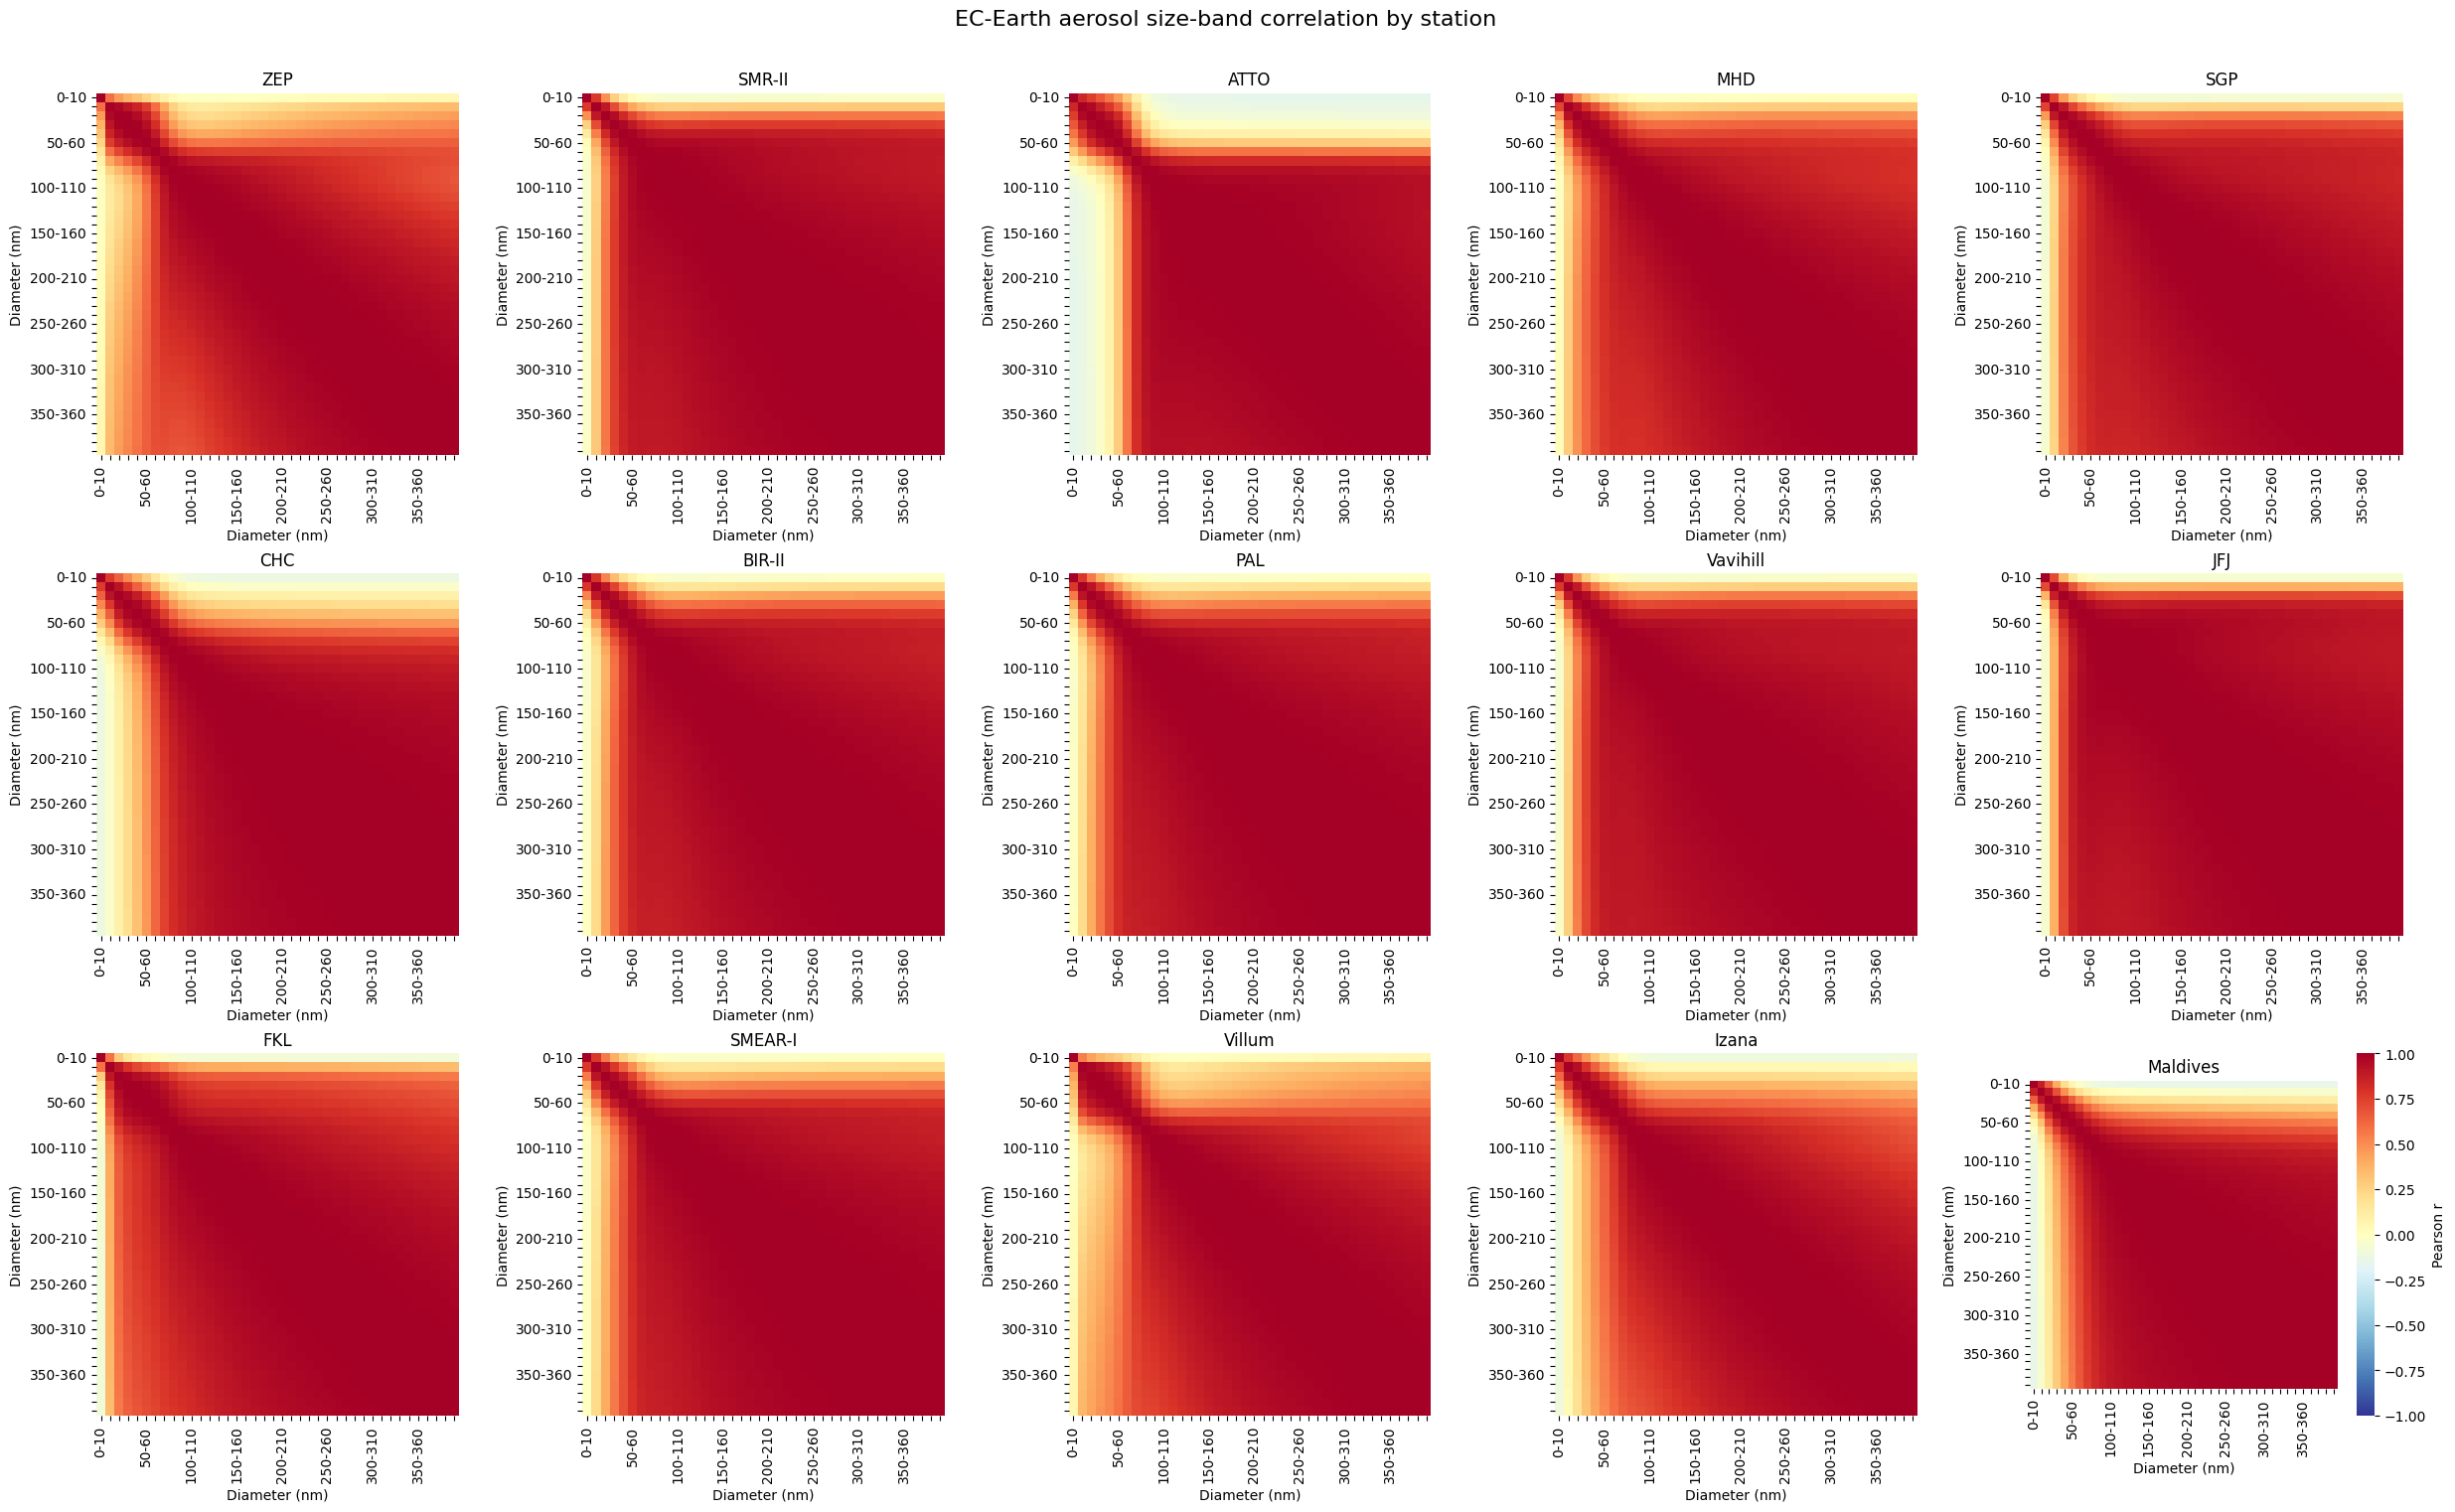

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(25, 15))
for idx, station in enumerate(ec_stations):
    ax = axes[idx // 5, idx % 5]
    cm = correlation_matrix(ec_bands, station_idx=idx)
    plot_corr_heatmap(cm, ec_labels, ax=ax, title=str(station),
                      show_cbar=(idx == len(ec_stations) - 1))
for j in range(len(ec_stations), axes.size):
    axes.flat[j].axis("off")
fig.suptitle("EC-Earth aerosol size-band correlation by station", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

### Optional — persist EC-Earth per-station matrices

In [10]:
# ec_corr_matrices = all_station_matrices(ec_bands)
# ECCorrMat_ds = xr.Dataset(
#     {"corr": (["station", "bin_x", "bin_y"], ec_corr_matrices)},
#     coords={"station": ec_stations, "bin_x": ec_labels, "bin_y": ec_labels},
# )
# ECCorrMat_ds.to_netcdf("/share/pech2273/ECESMcorr_matrices.nc")